<a href="https://colab.research.google.com/github/Prajit-B/Interpretable-RL-Based-Sleep-Stagging/blob/main/ClassiffierTrial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# === INSTALLS ===
!pip install -q catboost lightgbm xgboost
!pip install -q matplotlib seaborn scikit-learn pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.2 MB/s eta 0:00:00


In [ ]:
# === COMMON IMPORTS & PREPROCESSING ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# === LOAD DATASET ===
print("📤 Upload your dataset CSV")
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# === SPLIT DATA ===
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Second split: 50% of temp → validation (15%), 50% → test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"✅ Train shape: {X_train.shape}, Test shape: {X_test.shape}")


📤 Upload your dataset CSV


Saving selected_features_penalty_0.001.csv to selected_features_penalty_0.001.csv
✅ Train shape: (4200, 20), Test shape: (900, 20)


Random Forest Accuracy: 0.8756
Classification Report:
                precision    recall  f1-score   support

Sleep stage 1       0.92      0.98      0.95       150
Sleep stage 2       0.89      0.75      0.81       150
Sleep stage 3       0.72      0.74      0.73       150
Sleep stage 4       0.83      0.85      0.84       150
Sleep stage R       0.96      0.97      0.96       150
Sleep stage W       0.94      0.97      0.95       150

     accuracy                           0.88       900
    macro avg       0.88      0.88      0.87       900
 weighted avg       0.88      0.88      0.87       900



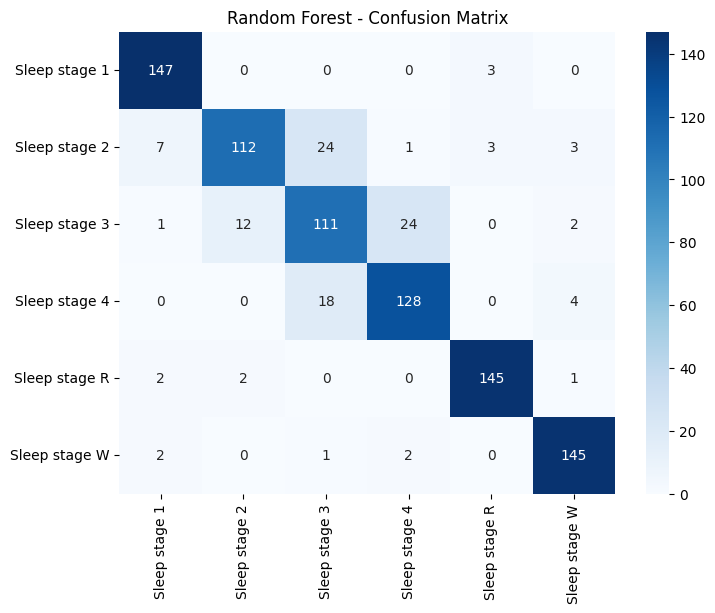

In [ ]:
# === SUPER TUNED RANDOM FOREST ===
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=20,
    max_features='sqrt',
    min_samples_split=2,
    min_samples_leaf=2,  # helps generalization
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(f'Random Forest Accuracy: {acc_rf:.4f}')
print('Classification Report:\n', classification_report(y_test, y_pred_rf))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Random Forest - Confusion Matrix')
plt.show()


CatBoost Accuracy: 0.8733
Classification Report:
                precision    recall  f1-score   support

Sleep stage 1       0.90      0.96      0.93       150
Sleep stage 2       0.87      0.77      0.82       150
Sleep stage 3       0.75      0.72      0.73       150
Sleep stage 4       0.82      0.88      0.85       150
Sleep stage R       0.95      0.93      0.94       150
Sleep stage W       0.95      0.98      0.96       150

     accuracy                           0.87       900
    macro avg       0.87      0.87      0.87       900
 weighted avg       0.87      0.87      0.87       900



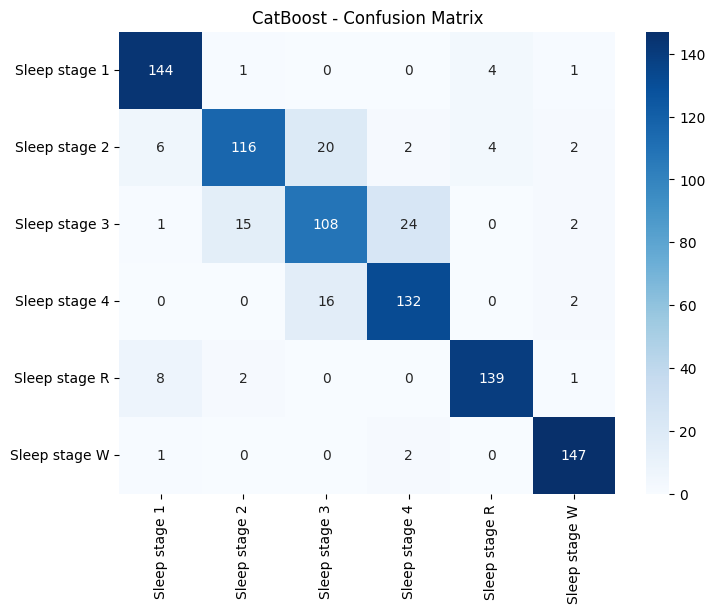

In [ ]:
# === SUPER TUNED CATBOOST ===
!pip install -q catboost
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.02,
    depth=10,
    eval_metric='Accuracy',
    random_seed=42,
    early_stopping_rounds=100,
    verbose=0
)

cat_model.fit(X_train, y_train, eval_set=(X_val, y_val))
y_pred_cat = cat_model.predict(X_test)

acc_cat = accuracy_score(y_test, y_pred_cat)
cm_cat = confusion_matrix(y_test, y_pred_cat)

print(f'CatBoost Accuracy: {acc_cat:.4f}')
print('Classification Report:\n', classification_report(y_test, y_pred_cat))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('CatBoost - Confusion Matrix')
plt.show()


In [ ]:
# === SUPER TUNED GRADIENT BOOSTING ===
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=10,
    subsample=0.8,  # prevents overfitting
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

acc_gb = accuracy_score(y_test, y_pred_gb)
cm_gb = confusion_matrix(y_test, y_pred_gb)

print(f'Gradient Boosting Accuracy: {acc_gb:.4f}')
print('Classification Report:\n', classification_report(y_test, y_pred_gb))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Gradient Boosting - Confusion Matrix')
plt.show()


In [ ]:
# === SUPER TUNED BAGGING ===
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=20, min_samples_leaf=2),  # stronger trees
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)

bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

acc_bag = accuracy_score(y_test, y_pred_bag)
cm_bag = confusion_matrix(y_test, y_pred_bag)

print(f'Bagging Accuracy: {acc_bag:.4f}')
print('Classification Report:\n', classification_report(y_test, y_pred_bag))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_bag, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Bagging - Confusion Matrix')
plt.show()


In [ ]:
# === SUPER TUNED VOTING CLASSIFIER ===
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(estimators=[
    ('RF', rf_model),
    ('GB', gb_model),
    ('CAT', cat_model)
], voting='soft', n_jobs=-1)

voting_model.fit(X_train, y_train)
y_pred_vote = voting_model.predict(X_test)

acc_vote = accuracy_score(y_test, y_pred_vote)
cm_vote = confusion_matrix(y_test, y_pred_vote)

print(f'Voting Classifier Accuracy: {acc_vote:.4f}')
print('Classification Report:\n', classification_report(y_test, y_pred_vote))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_vote, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Voting Classifier - Confusion Matrix')
plt.show()


Stacking Classifier Accuracy: 0.8911
Classification Report:
                precision    recall  f1-score   support

Sleep stage 1       0.96      0.98      0.97       150
Sleep stage 2       0.88      0.81      0.84       150
Sleep stage 3       0.74      0.75      0.75       150
Sleep stage 4       0.84      0.86      0.85       150
Sleep stage R       0.96      0.97      0.97       150
Sleep stage W       0.97      0.97      0.97       150

     accuracy                           0.89       900
    macro avg       0.89      0.89      0.89       900
 weighted avg       0.89      0.89      0.89       900



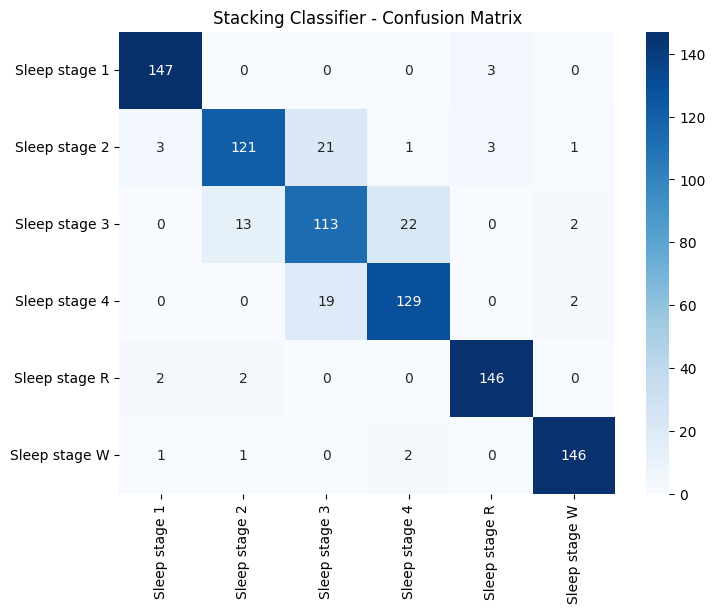

In [ ]:
# === SUPER TUNED STACKING CLASSIFIER ===
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

estimators_stack = [
    ('RF', RandomForestClassifier(n_estimators=1000, max_depth=20, max_features='sqrt', min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ('GB', GradientBoostingClassifier(n_estimators=1500, learning_rate=0.02, max_depth=10, subsample=0.8, random_state=42)),
    ('CAT', CatBoostClassifier(iterations=1500, learning_rate=0.02, depth=10, random_seed=42, verbose=0))
]

stacking_model = StackingClassifier(
    estimators=estimators_stack,
    final_estimator=LogisticRegression(max_iter=3000),  # stronger final model
    passthrough=True,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

acc_stack = accuracy_score(y_test, y_pred_stack)
cm_stack = confusion_matrix(y_test, y_pred_stack)

print(f'Stacking Classifier Accuracy: {acc_stack:.4f}')
print('Classification Report:\n', classification_report(y_test, y_pred_stack))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Stacking Classifier - Confusion Matrix')
plt.show()
